In [2]:
 %%script echo skipping
 """
urban_mining_refactored.ipynb
Detect urban settlement and mining in a single image
Calculate centroids of these categories and distance between them. Show on overlay image.

Problem: simiple arithmetic operations (NDBI) lump built environments and can not differentiate between urban settlement types (dense / sprawl / slum)
Solution: Supply sample areas, including negatives, to tune a simple classifier.
RTS with ChatGPT, Nov2025 / Jan2026

The script ingests a 10-band Sentinel-2 GeoTIFF and user-drawn scribbles for mining, urban, and background.
It builds spectral-texture features, trains simple centroid-based binary classifiers (mining vs non-mining, urban vs non-urban)
using positive and negative samples. Morphology, NDVI/NDBI gates and distance constraints reduce false positives,
producing final mining/urban masks and centroids.
"""

skipping


In [1]:
# variables specific to your CoLabsetup ----------------------------------------
from google.colab import drive
import sys

drive.mount('/content/drive')
root = '/content/drive/MyDrive/Colab/research/'
sys.path.append(root +"code/")
datapath = root + "data/"
ext_datapath = '/content/drive/MyDrive/+Projects/Nudge-X/sites/urban_mining/'
sys.path.append(root +'code/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%capture
!pip install rasterio
import rasterio

In [3]:
import os, math
import numpy as np
import rasterio
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# updated helper function
from urban_mining_helper_refactored_clean import *

In [4]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------

# 5-band Sentinel-2 stack
#MULTIBAND = "RixCreekOpenCutMine_urban_mining_2024-12-29.tif"
#MULTIBAND = "GarzweilerOpenPitMine_urban_mining_2024-10-23.tif"
#MULTIBAND = "LoolekopPipePalaboraMine_urban_mining_2024-11-18.tif"

MULTIBAND = "NyurbinskyOpenPit_urban_mining_2024-08-17.tif"
version = "_outlines_mb1.png"

MULTIBAND_PATH = ext_datapath + MULTIBAND
ANNOTATION = MULTIBAND.split('.tif')[0] + version
print(ANNOTATION)

SAMPLES_PATH = ext_datapath + ANNOTATION
OUT_PREFIX = os.path.splitext(MULTIBAND_PATH)[0]

# Colors for scribbles (you can add more examples)
# Each item is (R, G, B) in 0–255
MINING_COLORS = [
    (255,   0,   0),   # bright red
    # (r2, g2, b2),    # add more mining colors if needed
]

URBAN_COLORS = [
    (255, 255,   0),   # bright yellow
    # (r2, g2, b2),    # add more urban colors if needed
]

NEGATIVE_COLORS = [
    (  0, 0,  255),    # e.g. blue - choose whatever you draw as "background"
]

# Tolerance in RGB space (L1 distance) when matching scribble colors
COLOR_TOL = 25

# Limit negative training pixels per classifier (for speed)
MAX_NEG_TRAIN = 50000

# Min area (px) for final connected components
MINING_MIN_AREA =  2000
URBAN_MIN_AREA  =   800   #500

# Precision floors for threshold search (per class)
# Higher min precision: fewer false positives
MIN_PRECISION_MINING = 0.85
MIN_PRECISION_URBAN  = 0.80

# Negative exclusion radius (pixels) around blue scribbles
NEG_DILATE = 3    # 0 = only exact blue pixels; >0 = wider moat

# Optional max distance from scribbles (pixels); None = no limit
MAX_DIST_PX_MINING = 300           #None    # e.g. 250
MAX_DIST_PX_URBAN  = 300           #None    # e.g. 250

# Optional simple spectral gates
# If the yellow spill is mostly on bushy / scrubby areas, lowering URBAN_NDVI_MAX is effective
USE_SPECTRAL_GATES = True
MINING_NDVI_MAX = 0.45
MINING_NDBI_MIN = 0.00
URBAN_NDVI_MAX  = 0.50   #0.7


NyurbinskyOpenPit_urban_mining_2024-08-17_outlines_mb1.png


In [5]:
def main():
    # Tunable parameters (local) — unchanged
    MINE_WATER_KEEP_DIST_PX = 30
    COLOR_TOL_U8_MIN = 3
    MINING_GATE_RELAX_DIST_PX = 70

    if not os.path.exists(MULTIBAND_PATH):
        raise SystemExit(f"GeoTIFF not found: {MULTIBAND_PATH}")
    if not os.path.exists(SAMPLES_PATH):
        raise SystemExit(f"Sample image not found: {SAMPLES_PATH}")

    bands, profile = load_multiband_stack(MULTIBAND_PATH)
    samples_rgb, bands_aligned, profile, (H, W) = load_and_align_samples(SAMPLES_PATH, bands, profile)

    feat_stack, X_all, valid, aux = compute_features(bands_aligned)
    H2, W2, _ = feat_stack.shape
    # keep exact behavior: enforce samples dims to feature dims before extraction
    samples_rgb, mining_sample, urban_sample, neg_sample = extract_samples(
        samples_rgb, H2, W2,
        MINING_COLORS, URBAN_COLORS, NEGATIVE_COLORS,
        COLOR_TOL, COLOR_TOL_U8_MIN
    )

    model_tuple = train_classifiers(
        X_all, valid, mining_sample, urban_sample, neg_sample,
        MAX_NEG_TRAIN, MIN_PRECISION_MINING, MIN_PRECISION_URBAN
    )

    mine_mask, urban_mask = apply_and_postprocess(
        X_all, valid, H2, W2,
        mining_sample, urban_sample, neg_sample,
        aux,
        model_tuple,
        MINE_WATER_KEEP_DIST_PX,
        MINING_GATE_RELAX_DIST_PX,
        USE_SPECTRAL_GATES,
        MINING_NDVI_MAX, MINING_NDBI_MIN, URBAN_NDVI_MAX,
        MINING_MIN_AREA, URBAN_MIN_AREA,
        NEG_DILATE,
        MAX_DIST_PX_MINING, MAX_DIST_PX_URBAN
    )

    print("Final mining pixels:", int(mine_mask.sum()))
    print("Final urban pixels :", int(urban_mask.sum()))
    print("Extra mining pixels outside samples:", int((mine_mask & ~mining_sample).sum()))
    print("Extra urban pixels outside samples :", int((urban_mask & ~urban_sample).sum()))

    cx_m_px, cy_m_px, cx_u_px, cy_u_px = compute_centroids_and_report(mine_mask, urban_mask, profile)

    # use nir already scaled in aux for overlay background (matches baseline's `nir`)
    overlay_and_save(mine_mask, urban_mask, aux["nir"], OUT_PREFIX, cx_m_px, cy_m_px, cx_u_px, cy_u_px)


Resized sample image from (770, 770) -> (1005, 1006) using NEAREST.
samples_rgb dtype/min/max: uint8 0 255
Top bright colors (RGB,count): [((np.uint8(0), np.uint8(0), np.uint8(255)), np.int64(8962)), ((np.uint8(255), np.uint8(0), np.uint8(0)), np.int64(7019)), ((np.uint8(255), np.uint8(255), np.uint8(0)), np.int64(1233)), ((np.uint8(1), np.uint8(1), np.uint8(248)), np.int64(147)), ((np.uint8(1), np.uint8(1), np.uint8(247)), np.int64(70)), ((np.uint8(2), np.uint8(2), np.uint8(248)), np.int64(65)), ((np.uint8(1), np.uint8(2), np.uint8(248)), np.int64(63)), ((np.uint8(255), np.uint8(8), np.uint8(8)), np.int64(56)), ((np.uint8(255), np.uint8(32), np.uint8(32)), np.int64(43)), ((np.uint8(0), np.uint8(1), np.uint8(247)), np.int64(26))]
Sample pixels – mining: 111776 urban: 5476 negative: 54896
Training mining classifier...
  pos samples: 111776 neg samples: 50000
Training urban classifier...
  pos samples: 5476 neg samples: 50000
Applying classifiers to full image...
Final mining pixels: 170

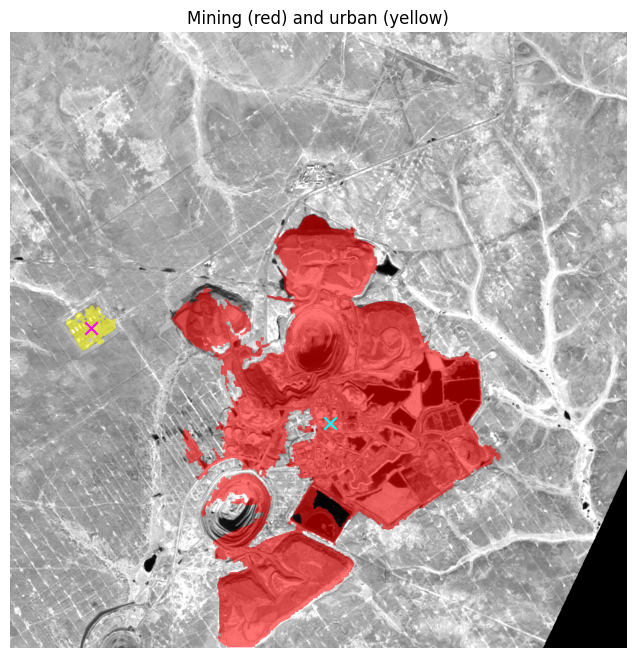

Saved:
   /content/drive/MyDrive/+Projects/Nudge-X/sites/urban_mining/NyurbinskyOpenPit_urban_mining_2024-08-17_overlay.png


In [6]:
if __name__ == "__main__":
    main()